# **2. Preparación de datos**

## **2.1. Agregación diaria**

### **1. Twitter(X)**

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
from pyGRNN import GRNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from itertools import product
import torch

In [31]:
# Paso 2.1 - Agregación diaria por candidato y plataforma (Twitter)
# Objetivo: obtener TwitterAGG (sumas) y TwitterAVG (promedios) AMBAS con todas las combinaciones account × fecha

# === 1) Parámetros de fechas ===
fecha_inicio = "2025-05-18"
fecha_fin    = "2025-10-18"

# === 2) Cargar dataset ===
df = pd.read_excel("C:/Users/juansoag/Downloads/Github/Avances_tesis/Bolivia/Scrapping data Bolivia.xlsx", sheet_name="Twitter")

# === 3) Parseo de fechas y selección de columnas ===
df['createdAt'] = pd.to_datetime(df['createdAt'], errors='coerce').dt.date
numeric_cols = ["shares", "replyCount", "likes", "viewCount"]
df[numeric_cols] = df[numeric_cols].fillna(0)
df = df[["id", "account", "createdAt", "shares", "replyCount", "likes", "viewCount"]]

# Renombrar cuentas para mayor claridad
def rename_account(account,Paz,Quiroga):
    if account == Paz:
        return 'Paz'
    elif account == Quiroga:
        return 'Quiroga'
    else:
        return account 
    
df['account'] = df['account'].apply(lambda x: rename_account(x,'Rodrigo_PazP','tutoquiroga'))

# === 4) Agregación cruda (solo días con posts) ===
twitter_agg_raw = (
    df.groupby(['account', 'createdAt'], as_index=False)
      .agg(
          posts   = ('id', 'count'),
          likes   = ('likes', 'sum'),
          comments= ('replyCount', 'sum'),
          shares  = ('shares', 'sum'),
          views   = ('viewCount', 'sum')
      )
)

# === 5) Construir TODAS las combinaciones account × fecha (rango fijo) ===
accounts = twitter_agg_raw['account'].unique()
fechas = [d.date() for d in pd.date_range(start=fecha_inicio, end=fecha_fin)]

base = pd.DataFrame(
    [(a, f) for a in accounts for f in fechas],
    columns=['account', 'createdAt']
)

# === 6) Extender AGG: LEFT merge para conservar TODAS las combinaciones ===
twitter_agg = base.merge(
    twitter_agg_raw,
    on=['account', 'createdAt'],
    how='left'
)

# Rellenar días sin publicaciones con 0 (AGG extendido)
for col in ['posts', 'likes', 'comments', 'shares', 'views']:
    twitter_agg[col] = twitter_agg[col].fillna(0)

# Asegurar tipos numéricos razonables
twitter_agg = twitter_agg.infer_objects(copy=False)

# === 7) Construir AVG a partir del AGG extendido (mismas filas) ===
twitter_avg = twitter_agg.copy()
twitter_avg['likes']    = twitter_agg['likes']    / twitter_agg['posts'].replace(0, pd.NA)
twitter_avg['comments'] = twitter_agg['comments'] / twitter_agg['posts'].replace(0, pd.NA)
twitter_avg['shares']   = twitter_agg['shares']   / twitter_agg['posts'].replace(0, pd.NA)
twitter_avg['views']    = twitter_agg['views']    / twitter_agg['posts'].replace(0, pd.NA)

# Si no hubo posts, los promedios deben ser 0
twitter_avg = twitter_avg.fillna(0).infer_objects(copy=False)

# Unimos ambas tablas en un solo dataframe usando las fechas
twitter_final = twitter_agg.merge(
    twitter_avg,
    on=['account', 'createdAt'],
    suffixes=('agg', 'avg')
)

C:\Users\juansoag\AppData\Local\Temp\ipykernel_5860\3005168038.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  twitter_avg = twitter_avg.fillna(0).infer_objects(copy=False)


### **2. Facebook**

In [32]:
# Paso 2.1 - Agregación diaria por candidato y plataforma (Facebook)
# Objetivo: obtener FacebookAGG (sumas) y FacebookAVG (promedios) AMBAS con todas las combinaciones account × fecha

# === 1) Parámetros de fechas ===
fecha_inicio = "2025-05-18"
fecha_fin    = "2025-10-18"

# === 2) Cargar dataset ===
df = pd.read_excel("C:/Users/juansoag/Downloads/Github/Avances_tesis/Bolivia/Scrapping data Bolivia.xlsx", sheet_name="Facebook")

# Eliminamos duplicados por el postId tomando la primera ocurrencia
df = df.drop_duplicates(subset=['postId'], keep='first')

# === 3) Parseo de fechas y selección de columnas ===
# Tomamos los primeros 10 caracteres de 'time' para evitar problemas con zonas horarias
df["createdAt"] = df["time"].str[:10]
df['createdAt'] = pd.to_datetime(df['createdAt'], errors='coerce').dt.date
numeric_cols = ["likes", "comments", "shares"]
df[numeric_cols] = df[numeric_cols].fillna(0)
vars = ["postId", "Username", "createdAt", "likes", "comments", "shares"]
df = df[vars]

# Renombrar cuentas usando la misma función que para Twitter (se asume que existe)
df['Username'] = df['Username'].apply(lambda x: rename_account(x,'Senador Rodrigo Paz','Jorge Tuto Quiroga Ramirez'))

# === 4) Agregación cruda (solo días con posts) ===
facebook_agg_raw = (
    df.groupby(['Username', 'createdAt'], as_index=False)
      .agg(
          posts   = ('postId', 'count'),
          likes   = ('likes', 'sum'),
          comments= ('comments', 'sum'),
          shares  = ('shares', 'sum')
      )
)

# === 5) Construir TODAS las combinaciones account × fecha (rango fijo) ===
accounts = facebook_agg_raw['Username'].unique()
fechas = [d.date() for d in pd.date_range(start=fecha_inicio, end=fecha_fin)]  # evita .date directo sobre el rango

base = pd.DataFrame(
    [(a, f) for a in accounts for f in fechas],
    columns=['Username', 'createdAt']
)

# === 6) Extender AGG: LEFT merge para conservar TODAS las combinaciones ===
facebook_agg = base.merge(
    facebook_agg_raw,
    on=['Username', 'createdAt'],
    how='left'
)

# Rellenar días sin publicaciones con 0 (AGG extendido)
# FIX: incluir 'posts' en el fillna (antes no se rellenaba y quedaba NaN)
for col in ["posts", "likes", "comments", "shares"]:
    facebook_agg[col] = facebook_agg[col].fillna(0)

# Asegurar tipos numéricos razonables
facebook_agg = facebook_agg.infer_objects(copy=False)

# === 7) Construir AVG a partir del AGG extendido (mismas filas) ===
facebook_avg = facebook_agg.copy()

# FIX: calcular los promedios EN facebook_avg (no en facebook_agg)
facebook_avg['likes']    = facebook_agg['likes']    / facebook_agg['posts'].replace(0, pd.NA)
facebook_avg['comments'] = facebook_agg['comments'] / facebook_agg['posts'].replace(0, pd.NA)
facebook_avg['shares']   = facebook_agg['shares']   / facebook_agg['posts'].replace(0, pd.NA)

# Si no hubo posts, los promedios deben ser 0
facebook_avg = facebook_avg.fillna(0).infer_objects(copy=False)

facebook_final = facebook_agg.merge(
    facebook_avg,
    on=['Username', 'createdAt'],
    suffixes=('_agg', '_avg')
)


C:\Users\juansoag\AppData\Local\Temp\ipykernel_5860\3574080505.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  facebook_avg = facebook_avg.fillna(0).infer_objects(copy=False)


### **3. Instagram**

In [33]:
# Paso 2.1 - Agregación diaria por candidato y plataforma (Instagram)
# Objetivo: obtener InstagramAGG (sumas) y InstagramAVG (promedios) AMBAS con todas las combinaciones account × fecha

# === 1) Parámetros de fechas ===
fecha_inicio = "2025-05-18"
fecha_fin    = "2025-10-18"

# === 2) Cargar dataset ===
df = pd.read_excel("C:/Users/juansoag/Downloads/Github/Avances_tesis/Bolivia/Scrapping data Bolivia.xlsx", sheet_name="Instagram")

# Eliminamos duplicados por el postId tomando la primera ocurrencia
df = df.drop_duplicates(subset=['postId'], keep='first')

# === 3) Parseo de fechas y selección de columnas ===
df["timestamp"] = df["timestamp"].str[:10]
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce').dt.date
numeric_cols = ["likes", "comments", "views"]
df[numeric_cols] = df[numeric_cols].fillna(0)
vars = ["postId", "Username", "timestamp", "likes", "comments", "views"]
df = df[vars]

# Renombrar cuentas (misma lógica que Twitter)
df['Username'] = df['Username'].apply(lambda x: rename_account(x, 'Rodrigo Paz', 'Tuto Quiroga'))

# Eliminar cuentas no relevantes
df = df[~df['Username'].isin(['JP Velasco', 'Vittorio Aloisio Zenteno'])]

# === 4) Agregación cruda (solo días con posts) ===
instagram_agg_raw = (
    df.groupby(['Username', 'timestamp'], as_index=False)
      .agg(
          posts   = ('postId', 'count'),
          likes   = ('likes', 'sum'),
          comments= ('comments', 'sum'),
          views   = ('views', 'sum')
      )
)

# === 5) Construir TODAS las combinaciones account × fecha (rango fijo) ===
accounts = instagram_agg_raw['Username'].unique()
fechas = [d.date() for d in pd.date_range(start=fecha_inicio, end=fecha_fin)]

base = pd.DataFrame(
    [(a, f) for a in accounts for f in fechas],
    columns=['Username', 'timestamp']
)

# === 6) Extender AGG con días vacíos ===
instagram_agg = base.merge(instagram_agg_raw, on=['Username', 'timestamp'], how='left')

# Rellenar días sin publicaciones con 0 (incluir posts)
for col in ["posts", "likes", "comments", "views"]:
    instagram_agg[col] = instagram_agg[col].fillna(0)

# Asegurar tipos numéricos
instagram_agg = instagram_agg.infer_objects(copy=False)

# === 7) Construir AVG a partir del AGG extendido (mismas filas) ===
instagram_avg = instagram_agg.copy()
instagram_avg['likes']    = instagram_agg['likes']    / instagram_agg['posts'].replace(0, pd.NA)
instagram_avg['comments'] = instagram_agg['comments'] / instagram_agg['posts'].replace(0, pd.NA)
instagram_avg['views']    = instagram_agg['views']    / instagram_agg['posts'].replace(0, pd.NA)

# Reemplazar NaN (días sin posts) por 0
instagram_avg = instagram_avg.fillna(0).infer_objects(copy=False)

# === 8) Unir ambas tablas ===
instagram_final = instagram_agg.merge(
    instagram_avg,
    on=['Username', 'timestamp'],
    suffixes=('_agg', '_avg')
)



C:\Users\juansoag\AppData\Local\Temp\ipykernel_5860\1551278280.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  instagram_avg = instagram_avg.fillna(0).infer_objects(copy=False)


### **4. TikTok**

In [34]:
# Paso 2.1 - Agregación diaria por candidato y plataforma (TikTok)
# Objetivo: obtener TikTokAGG (sumas) y TikTokAVG (promedios) AMBAS con todas las combinaciones account × fecha

# === 1) Parámetros de fechas ===
fecha_inicio = "2025-05-18"
fecha_fin    = "2025-10-18"

# === 2) Cargar dataset ===
df = pd.read_excel("C:/Users/juansoag/Downloads/Github/Avances_tesis/Bolivia/Scrapping data Bolivia.xlsx", sheet_name="TikTok")

# Eliminamos duplicados por el id tomando la primera ocurrencia
df = df.drop_duplicates(subset=['id'], keep='first')

# === 3) Parseo de fechas y selección de columnas ===
df["timestamp"] = df["timestamp"].str[:10]
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce').dt.date
numeric_cols = ["likes", "comments", "collects", "shares", "playCount"]
df[numeric_cols] = df[numeric_cols].fillna(0)
vars = ["id", "name", "timestamp", "likes", "comments", "collects", "shares", "playCount"]
df = df[vars]
# Renombrar cuentas (misma lógica que Twitter)
df['name'] = df['name'].apply(lambda x: rename_account(x, 'Rodrigo Paz', 'Tuto Quiroga'))

# === 4) Agregación cruda (solo días con posts) ===
tiktok_agg_raw = (
    df.groupby(['name', 'timestamp'], as_index=False)
      .agg(
          posts   = ('id', 'count'),
          likes   = ('likes', 'sum'),
          comments= ('comments', 'sum'),
          collects= ('collects', 'sum'),
          shares  = ('shares', 'sum'),
          playCount= ('playCount', 'sum')
      )
)

# === 5) Construir TODAS las combinaciones account × fecha (rango fijo) ===
accounts = tiktok_agg_raw['name'].unique()
fechas = [d.date() for d in pd.date_range(start=fecha_inicio, end=fecha_fin)]

base = pd.DataFrame(
    [(a, f) for a in accounts for f in fechas],
    columns=['name', 'timestamp']
)

# === 6) Extender AGG con días vacíos ===
tiktok_agg = base.merge(tiktok_agg_raw, on=['name', 'timestamp'], how='left')

# Rellenar días sin publicaciones con 0 (incluir posts)
for col in ["posts", "likes", "comments", "collects", "shares", "playCount"]:
    tiktok_agg[col] = tiktok_agg[col].fillna(0)

# Asegurar tipos numéricos
tiktok_agg = tiktok_agg.infer_objects(copy=False)

# === 7) Construir AVG a partir del AGG extendido (mismas filas) ===
tiktok_avg = tiktok_agg.copy()
tiktok_avg['likes']    = tiktok_agg['likes']    / tiktok_agg['posts'].replace(0, pd.NA)
tiktok_avg['comments'] = tiktok_agg['comments'] / tiktok_agg['posts'].replace(0, pd.NA)
tiktok_avg['collects'] = tiktok_agg['collects'] / tiktok_agg['posts'].replace(0, pd.NA)
tiktok_avg['shares']   = tiktok_agg['shares']   / tiktok_agg['posts'].replace(0, pd.NA)
tiktok_avg['playCount']    = tiktok_agg['playCount']    / tiktok_agg['posts'].replace(0, pd.NA)

# Reemplazar NaN (días sin posts) por 0
tiktok_avg = tiktok_avg.fillna(0).infer_objects(copy=False)

# === 8) Unir ambas tablas ===
tiktok_final = tiktok_agg.merge(
    tiktok_avg,
    on=['name', 'timestamp'],
    suffixes=('_agg', '_avg')
)



C:\Users\juansoag\AppData\Local\Temp\ipykernel_5860\732087890.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tiktok_avg = tiktok_avg.fillna(0).infer_objects(copy=False)


### **Construcción del dataset final**

In [35]:
# === 1. Asegurar columnas de fecha y cuenta consistentes ===
facebook_final.rename(columns={'Username': 'account', 'createdAt': 'date'}, inplace=True)
twitter_final.rename(columns={'account': 'account', 'createdAt': 'date'}, inplace=True)
instagram_final.rename(columns={'Username': 'account', 'timestamp': 'date'}, inplace=True)
tiktok_final.rename(columns={'name': 'account', 'timestamp': 'date'}, inplace=True)
# === 2. Seleccionar y renombrar variables según la Tabla 2 ===
# Renombrar columnas de Facebook
facebook_final = facebook_final.rename(columns={
    'posts_agg': 'FBPosts',
    'likes_agg': 'FBLikes',
    'shares_agg': 'FBShares',
    'comments_agg': 'FBComments',
    'likes_avg': 'FBLikesPPost',
    'shares_avg': 'FBSharesPPost',
    'comments_avg': 'FBCommentsPPost'
})

# Renombrar columnas de Twitter
twitter_final = twitter_final.rename(columns={
    'postsagg': 'TTPosts',
    'likesagg': 'TTLikes',
    'sharesagg': 'TTRetweets',
    'likesavg': 'TTLikesPPost',
    'sharesavg': 'TTRetweetsPPost'
})

# Renombrar columnas de Instagram
instagram_final = instagram_final.rename(columns={
    'posts_agg': 'IGPosts',
    'likes_agg': 'IGLikes',
    'comments_agg': 'IGComments',
    'likes_avg': 'IGLikesPPost',
    'comments_avg': 'IGCommentsPPost'
})

# Renombrar columnas de TikTok
tiktok_final = tiktok_final.rename(columns={
    'posts_agg': 'TTKPosts',
    'likes_agg': 'TTKLikes',
    'comments_agg': 'TTKComments',
    'shares_agg': 'TTKShares',
    'favorites_agg': 'TTKFavorites',
    'likes_avg': 'TTKLikesPPost',
    'comments_avg': 'TTKCommentsPPost',
    'shares_avg': 'TTKSharesPPost',
    'favorites_avg': 'TTKFavoritesPPost'
})

# Unir todo por cuenta y fecha (outer join)
social_final = (
    facebook_final
    .merge(twitter_final, on=['account', 'date'], how='outer')
    .merge(instagram_final, on=['account', 'date'], how='outer')
    .merge(tiktok_final, on=['account', 'date'], how='outer')
    .fillna(0)
    .infer_objects(copy=False)
)

In [36]:
# === 2. Definir las columnas que quieres conservar ===

cols_tabla2 = [
    # Claves
    'account', 'date',

    # --- Facebook ---
    'FBPosts', 'FBLikes', 'FBShares', 'FBComments',
    'FBLikesPPost', 'FBSharesPPost', 'FBCommentsPPost',

    # --- Twitter / X ---
    'TTPosts', 'TTLikes', 'TTRetweets',
    'TTLikesPPost', 'TTRetweetsPPost',

    # --- Instagram ---
    'IGPosts', 'IGLikes', 'IGComments',
    'IGLikesPPost', 'IGCommentsPPost',

    # --- TikTok ---
    'TTKPosts', 'TTKLikes', 'TTKComments', 'TTKShares', 'TTKFavorites',
    'TTKLikesPPost', 'TTKCommentsPPost', 'TTKSharesPPost', 'TTKFavoritesPPost'
]

# === 2. Filtrar el DataFrame ===
social_filtered = social_final[[c for c in cols_tabla2 if c in social_final.columns]].copy()

# === 3. Verificación ===
print(" Dataset filtrado según Tabla 2")
print("Filas:", len(social_filtered))
print("Columnas:", len(social_filtered.columns))
print("Columnas incluidas:", social_filtered.columns.tolist()[:10], "...")
social_filtered
# === Guardar dataset filtrado en Excel ===
output_path = "C:/Users/juansoag/Downloads/Github/Avances_tesis/Bolivia/SocialMedia_FinalDataset.xlsx"

social_filtered.to_excel(output_path, index=False, sheet_name='SocialData')

print(f"Archivo guardado correctamente en:\n{output_path}")
print("Filas:", len(social_filtered), " | Columnas:", len(social_filtered.columns))

 Dataset filtrado según Tabla 2
Filas: 308
Columnas: 26
Columnas incluidas: ['account', 'date', 'FBPosts', 'FBLikes', 'FBShares', 'FBComments', 'FBLikesPPost', 'FBSharesPPost', 'FBCommentsPPost', 'TTPosts'] ...
Archivo guardado correctamente en:
C:/Users/juansoag/Downloads/Github/Avances_tesis/Bolivia/SocialMedia_FinalDataset.xlsx
Filas: 308  | Columnas: 26


## **2.2. Normalización**

In [37]:
# === 1️ Cargar datos ===
df = pd.read_excel("SocialMedia_FinalDataset.xlsx")

# === 2️ Diccionario de columnas por red ===
redes = {
    'FB': ['FBPosts','FBLikes','FBShares','FBComments'],
    'TT': ['TTPosts','TTLikes','TTRetweets'],
    'IG': ['IGPosts','IGLikes','IGComments'],
    'TTK': ['TTKPosts','TTKLikes','TTKComments','TTKShares']
}

# === 3️ Normalización: promedio por publicación ===
for prefix, cols in redes.items():
    n_posts = cols[0]
    for col in cols[1:]:
        new_col = col + 'PPost'
        df[new_col] = df.apply(lambda x: x[col] / x[n_posts] if x[n_posts] > 0 else 0, axis=1)

# === 4️ Estandarización intra-plataforma (z-score) ===
scaler = StandardScaler()

for prefix in redes.keys():
    # Selecciona todas las columnas que comiencen con el prefijo (ej. 'FB', 'TT', etc.)
    cols_prefijo = [c for c in df.columns if c.startswith(prefix)]
    df[cols_prefijo] = scaler.fit_transform(df[cols_prefijo])


def normalizar_y_suavizar(df, columnas_id, columnas_features, window=1, por_cuenta=True):
    """
    Normaliza las variables de un DataFrame y aplica una media móvil de n periodos.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con las variables a normalizar.
    columnas_id : list[str]
        Columnas que no deben ser normalizadas (ej. ['account', 'date']).
    columnas_features : list[str]
        Columnas numéricas que se deben normalizar.
    window : int
        Número de periodos para la media móvil. (1 = sin suavizado)
    por_cuenta : bool
        Si True, normaliza de forma independiente por cada cuenta (recomendado para redes sociales).

    Retorna
    -------
    df_final : pd.DataFrame
        DataFrame con las variables normalizadas y suavizadas.
    """

    scaler = MinMaxScaler(feature_range=(0, 1))
    df_result = []

    if por_cuenta:
        # Normalización independiente por cuenta
        for cuenta, grupo in df.groupby('account'):
            g = grupo.copy().sort_values(by=columnas_id[1])  # orden temporal
            g[columnas_features] = scaler.fit_transform(g[columnas_features])

            # Aplicar media móvil si window > 1
            if window > 1:
                g[columnas_features] = g[columnas_features].rolling(window=window, min_periods=1).mean()

            df_result.append(g)
        df_final = pd.concat(df_result, ignore_index=True)
    else:
        # Normalización global (todo el dataset junto)
        df_final = df.copy()
        df_final[columnas_features] = scaler.fit_transform(df[columnas_features])

        if window > 1:
            df_final = df_final.sort_values(by=columnas_id)
            df_final[columnas_features] = df_final[columnas_features].rolling(window=window, min_periods=1).mean()

    df_final = df_final.infer_objects(copy=False)
    return df_final

# Definir las columnas
cols_id = ['account', 'date']
cols_features = [c for c in social_filtered.columns if c not in cols_id]

# Aplicar la función: normalización + media móvil de 3 días
social_norm = normalizar_y_suavizar(
    df=social_filtered,
    columnas_id=cols_id,
    columnas_features=cols_features,
    window=2,           # media móvil
    por_cuenta=True     # normaliza dentro de cada candidato
)


## **2.3. Modelamiento**

In [38]:
# ========= 1) Encapsular encuestas → intención diaria =========
def daily_intent_from_polls(polls_df, election_date, election_result):
    """
    polls_df: DataFrame con columnas ['fecha','Quiroga','Paz'] en porcentajes (0-100 o 0-1)
    election_date: Timestamp('YYYY-MM-DD')
    election_result: dict {'Quiroga': 45.5, 'Paz': 54.5} en % o proporción
    """
    dfp = polls_df.copy()
    # Asegurar proporciones 0-1
    for c in ['Quiroga', 'Paz']:
        if dfp[c].max() > 1.0:
            dfp[c] = dfp[c] / 100.0

    # Normalizar cada medición a suma=1 (por si no cierran exactamente)
    s = dfp[['Quiroga', 'Paz']].sum(axis=1).replace(0, np.nan)
    dfp['Quiroga'] = dfp['Quiroga'] / s
    dfp['Paz'] = dfp['Paz'] / s

    # Añadir resultado de elección
    q_fin = election_result['Quiroga'] / 100.0 if election_result['Quiroga'] > 1 else election_result['Quiroga']
    p_fin = election_result['Paz'] / 100.0 if election_result['Paz'] > 1 else election_result['Paz']
    dfp = pd.concat(
        [dfp,
         pd.DataFrame([{'fecha': pd.to_datetime(election_date),
                        'Quiroga': q_fin, 'Paz': p_fin}])],
        ignore_index=True
    ).sort_values('fecha')

    # Interpolación diaria lineal
    idx = pd.date_range(dfp['fecha'].min(), dfp['fecha'].max(), freq='D')
    full = (dfp.set_index('fecha')
            .reindex(idx)
            .interpolate('linear')
            .bfill().ffill()
            .reset_index()
            .rename(columns={'index': 'fecha'}))
    return full  # columnas: fecha, Quiroga, Paz


# ========= 2) Preparar intención diaria y unir a social_norm =========
# Encuestas desde mayo a octubre

# Definir datos de encuestas y resultados electorales
polls = pd.DataFrame({
    'fecha': pd.to_datetime([
        '2025-05-26', '2025-06-14', '2025-06-20',
        '2025-07-07', '2025-07-10', '2025-07-27', '2025-07-28',
        '2025-08-03', '2025-08-04', '2025-08-06',
        '2025-09-25', '2025-10-06', '2025-10-07', '2025-10-09'
    ]),
    'Quiroga': [65, 78, 59, 64, 73, 69, 81, 71, 86, 71, 47.0, 44.4, 42.9, 44.9],
    'Paz':     [15, 20, 23, 11, 14, 20, 27, 23, 32, 29, 39.3, 36.2, 38.7, 36.5]
})

election_date = pd.Timestamp('2025-10-18')
election_result = {'Quiroga': 45.47, 'Paz': 54.53}


intento = daily_intent_from_polls(polls, election_date, election_result)
intento = intento.rename(columns={'fecha': 'date'})

df = social_norm.copy()
df['date'] = pd.to_datetime(df['date'])

# =========================================
# Paso 1. Preparar el dataset final para modelar
# - Mapear IntencionVotoReal por candidato
# - Asegurar tipos/orden y quitar NaN del target
# =========================================
df = df.copy()
df['date'] = pd.to_datetime(df['date'])

# Crear/llenar columna target
df['IntencionVotoReal'] = np.nan
for cand in ['Paz', 'Quiroga']:
    serie = intento.set_index('date')[cand]
    m = df['account'].str.lower() == cand.lower()
    df.loc[m, 'IntencionVotoReal'] = df.loc[m, 'date'].map(serie)

# Orden temporal y limpieza mínima
df = df.sort_values(['account', 'date'])
# (No eliminamos filas todavía; se filtran por ventana en el paso 2)

# =========================================
# Paso 2. Separar entrenamiento y proyección (ventanas temporales)
# - Entrenar hasta última encuesta; proyectar hasta el día de elección
# =========================================
first_poll = polls['fecha'].min()
last_poll  = polls['fecha'].max()
fin        = election_date

mask_train_window = (df['date'] >= first_poll) & (df['date'] <= last_poll)
mask_pred_window  = (df['date'] <= fin)

# =========================================
# Paso 3. Definir features (X) y target (y)
# - X: todas las numéricas excepto el target
# - y: IntencionVotoReal
# =========================================
X_all = df.select_dtypes(include=[np.number]).drop(columns=['IntencionVotoReal'], errors='ignore')
y_all = df['IntencionVotoReal']

# Creamos máscaras por candidato
mask_paz = df['account'].str.lower() == 'paz'
mask_q   = df['account'].str.lower() == 'quiroga'

# Conjuntos de entrenamiento (solo filas con y no nula)
train_idx_paz = (mask_paz & mask_train_window & y_all.notna())
train_idx_q   = (mask_q   & mask_train_window & y_all.notna())

# Conjuntos de predicción
pred_idx_paz = (mask_paz & mask_pred_window)
pred_idx_q   = (mask_q   & mask_pred_window)

X_train_paz = X_all.loc[train_idx_paz]
y_train_paz = y_all.loc[train_idx_paz].values
X_pred_paz  = X_all.loc[pred_idx_paz]
dates_paz   = df.loc[pred_idx_paz, 'date'].values  # para reubicar predicciones luego

X_train_q = X_all.loc[train_idx_q]
y_train_q = y_all.loc[train_idx_q].values
X_pred_q  = X_all.loc[pred_idx_q]
dates_q   = df.loc[pred_idx_q, 'date'].values

# =========================================
# Paso 4. Escalado sin fuga (fit SOLO en entrenamiento)
# - Se devuelve Xs_tr / Xs_pp por candidato
# =========================================
scaler_paz = StandardScaler().fit(X_train_paz)
Xs_tr_paz  = scaler_paz.transform(X_train_paz)
Xs_pp_paz  = scaler_paz.transform(X_pred_paz)

scaler_q = StandardScaler().fit(X_train_q)
Xs_tr_q  = scaler_q.transform(X_train_q)
Xs_pp_q  = scaler_q.transform(X_pred_q)

print("Listo: matrices de diseño preparadas.")
print(f"Paz -> train: {Xs_tr_paz.shape}, pred: {Xs_pp_paz.shape}")
print(f"Quiroga -> train: {Xs_tr_q.shape}, pred: {Xs_pp_q.shape}")

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
import torch
import numpy as np

# ============================================
# 1️⃣ Función GRNN (versión robusta)
# ============================================
def grnn_predict(X_train, y_train, X_test, sigma=None, k=0.6):
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32).view(-1)
    Xte = torch.tensor(X_test,  dtype=torch.float32)
    eps = 1e-12
    if sigma is None:
        idx = torch.randperm(Xtr.shape[0])[:min(800, Xtr.shape[0])]
        sub = Xtr[idx]
        dmat = torch.cdist(sub, sub, p=2)
        med = torch.median(dmat[dmat > 0.0]).item() if (dmat > 0).any() else 1.0
        sigma = max(med * k, 1e-3)
    sigma2 = float(sigma) ** 2
    preds = []
    with torch.no_grad():
        for x in Xte:
            d2 = torch.sum((Xtr - x) ** 2, dim=1)
            w = torch.exp(-d2 / (2 * sigma2))
            sw = torch.sum(w).item()
            yhat = (torch.sum(w * ytr).item() / (sw + eps)) if sw > eps else ytr[torch.argmin(d2)].item()
            preds.append(np.clip(yhat, 0, 1))
    return np.array(preds)


# ============================================
# 2️⃣ Función auxiliar para entrenar modelo
# ============================================
def entrenar_y_predecir(modelo, Xtr, ytr, Xpp, usar_pca=False, n_comp=6):
    if usar_pca:
        pca = PCA(n_components=min(n_comp, Xtr.shape[1]))
        Xtr_p = pca.fit_transform(Xtr)
        Xpp_p = pca.transform(Xpp)
    else:
        Xtr_p, Xpp_p = Xtr, Xpp

    nombre = modelo.__class__.__name__

    if nombre == "LinearRegression":
        modelo.fit(Xtr_p, ytr)
        y_pred = np.clip(modelo.predict(Xpp_p), 0, 1)

    elif nombre == "MLPRegressor":
        modelo.fit(Xtr_p, ytr)
        raw = np.clip(modelo.predict(Xpp_p), 0, 1)
        y_pred = raw.copy()
        for i in range(2, len(y_pred)):
            dp, dn = y_pred[i-1]-y_pred[i-2], raw[i]-y_pred[i-1]
            beta = 0.8 if np.sign(dp)!=np.sign(dn) else 0.6
            y_pred[i] = beta*y_pred[i-1] + (1-beta)*raw[i]

    elif nombre == "GRNN":
        y_pred = grnn_predict(Xtr_p, ytr, Xpp_p, sigma=None, k=0.6)
        for i in range(2, len(y_pred)):
            dp, dn = y_pred[i-1]-y_pred[i-2], y_pred[i]-y_pred[i-1]
            beta = 0.85 if np.sign(dp)!=np.sign(dn) else 0.65
            y_pred[i] = beta*y_pred[i-1] + (1-beta)*y_pred[i]

    return y_pred


# ============================================
# 3️⃣ Definir y entrenar todos los modelos
# ============================================
modelos = {
    "LinearRegression": LinearRegression(),
    "LinearRegression PCA": LinearRegression(),
    "MLP-BP": MLPRegressor(hidden_layer_sizes=(48,24), activation='relu',
                           solver='adam', learning_rate_init=3e-4,
                           alpha=0.02, max_iter=4000, random_state=42),
    "MLP-BP PCA": MLPRegressor(hidden_layer_sizes=(48,24), activation='relu',
                               solver='adam', learning_rate_init=3e-4,
                               alpha=0.02, max_iter=4000, random_state=42),
    "GRNN": "GRNN",  # se manejará aparte
    "GRNN PCA": "GRNN"
}

predicciones = {}

for nombre, modelo in modelos.items():
    usar_pca = "PCA" in nombre
    if "GRNN" in nombre:
        pred = entrenar_y_predecir(type("GRNN", (), {})(), Xs_tr_paz, y_train_paz, Xs_pp_paz, usar_pca=usar_pca)
    else:
        pred = entrenar_y_predecir(modelo, Xs_tr_paz, y_train_paz, Xs_pp_paz, usar_pca=usar_pca)
    predicciones[nombre] = pred


# ============================================
# 4️⃣ Agregar resultados al DataFrame
# ============================================
for nombre, ypred in predicciones.items():
    col = nombre.replace(" ", "_")
    df[col] = np.nan
    df.loc[pred_idx_paz, col] = ypred
    df.loc[pred_idx_q, col]   = 1 - df.loc[pred_idx_q, 'date'].map(dict(zip(dates_paz, ypred)))

Listo: matrices de diseño preparadas.
Paz -> train: (137, 24), pred: (154, 24)
Quiroga -> train: (137, 24), pred: (154, 24)


# **Modelamiento base**

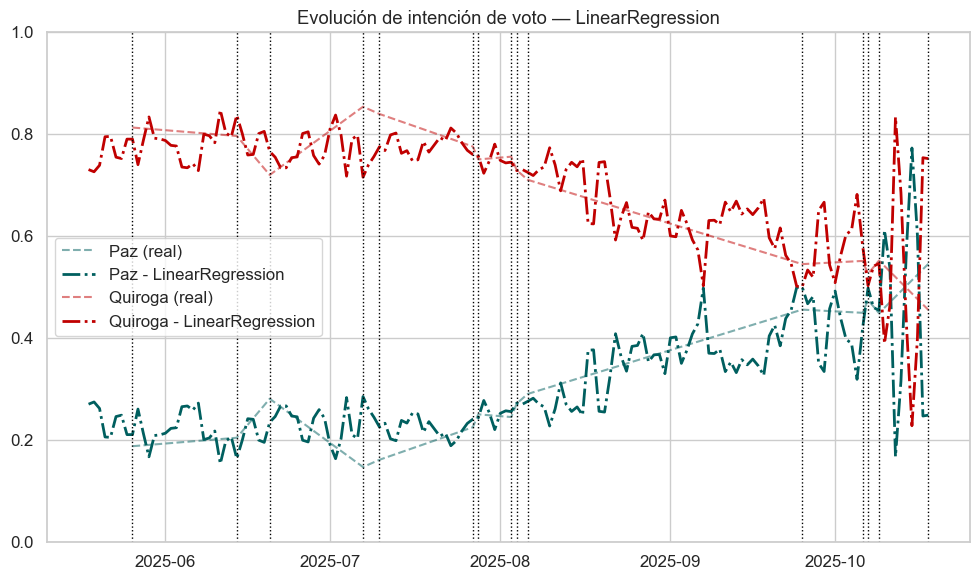

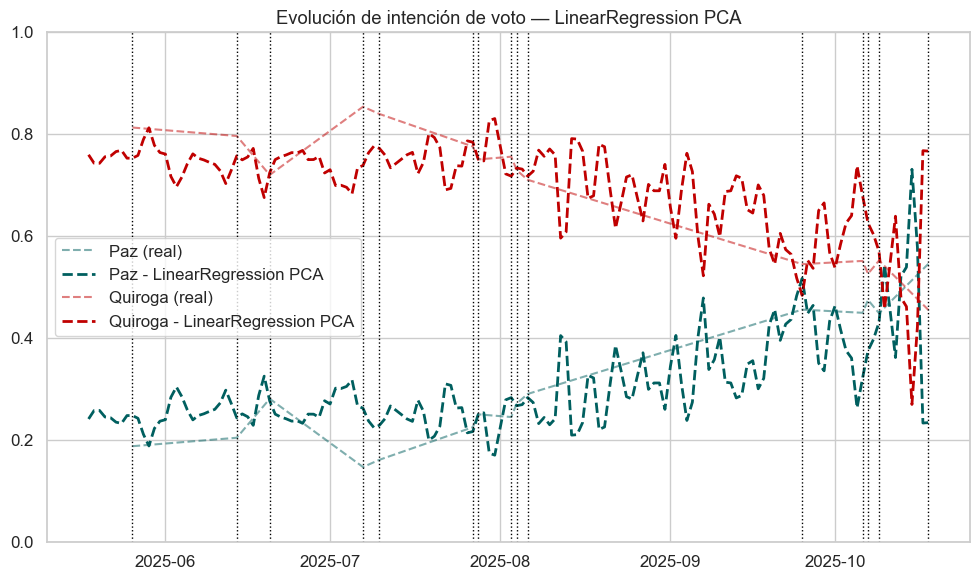

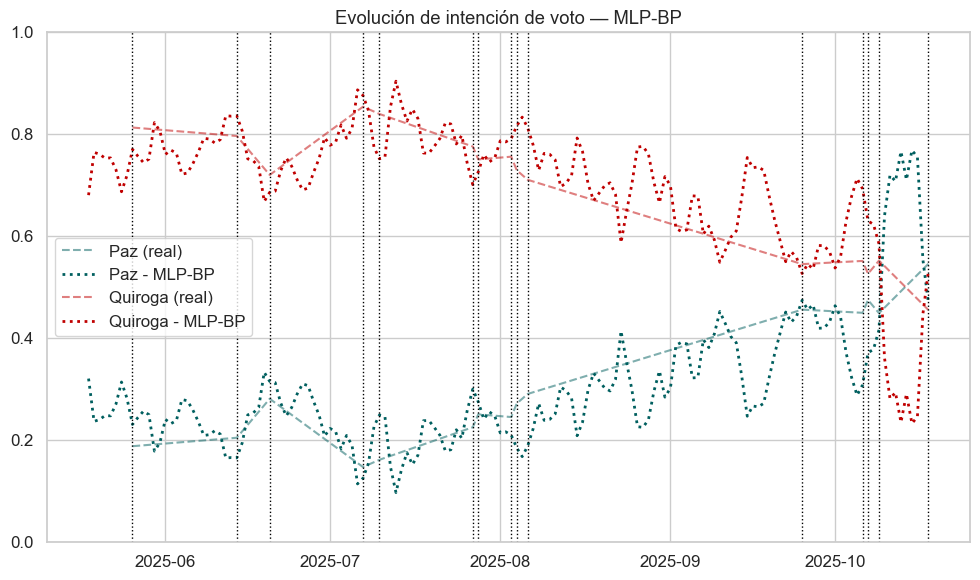

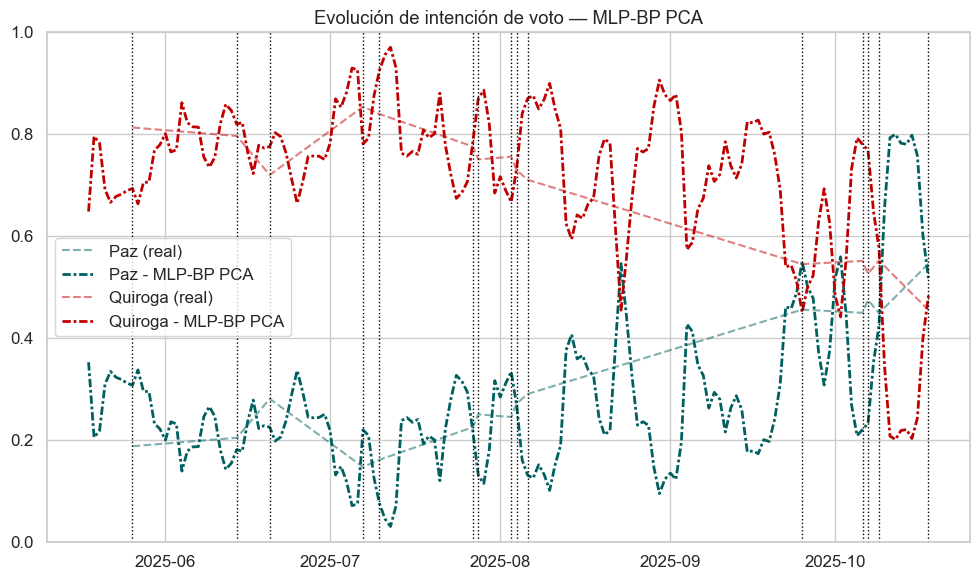

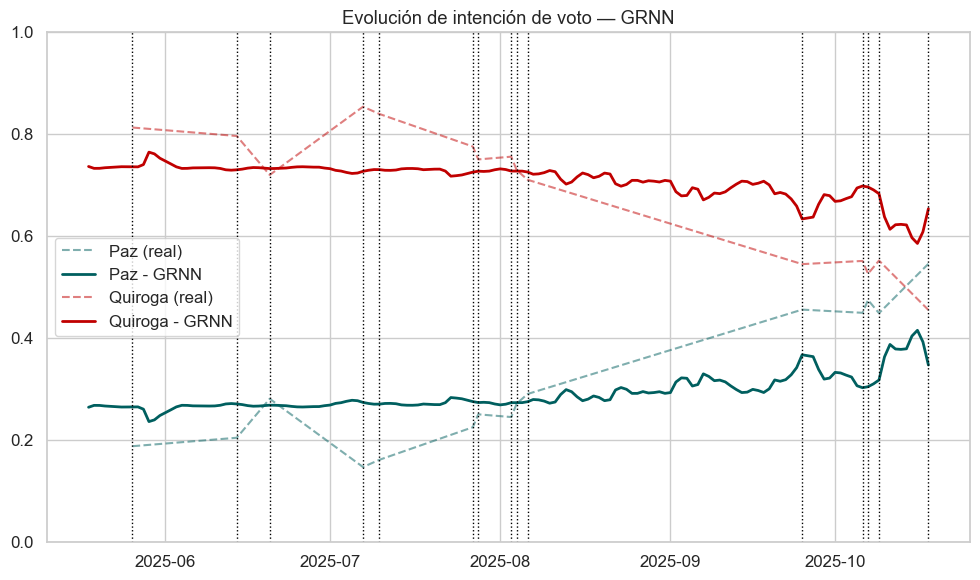

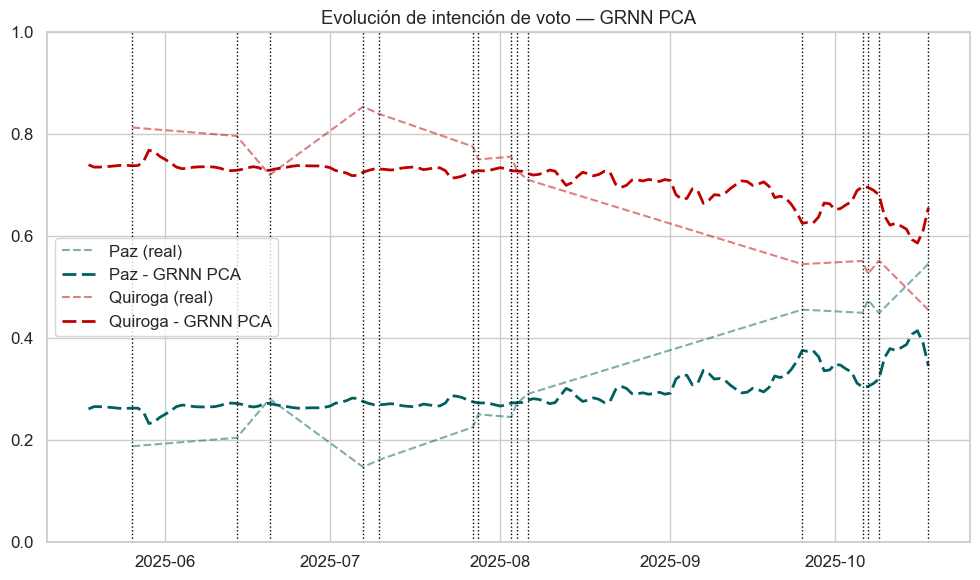

In [39]:

# ============================================
# 5️⃣ Gráficos comparativos
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.1)

colors = {'paz': '#005F5F', 'quiroga': '#C00000'}
linestyles = {
    'LinearRegression': '-.', 'LinearRegression PCA': '--',
    'MLP-BP': ':', 'MLP-BP PCA': (0,(3,1,1,1)),
    'GRNN': '-', 'GRNN PCA': (0,(5,2))
}

for nombre_modelo in modelos.keys():
    plt.figure(figsize=(10,6))
    for cand in ['Paz', 'Quiroga']:
        sub = df[df['account'].str.lower()==cand.lower()].sort_values('date')
        ckey = cand.lower()
        plt.plot(sub['date'], sub['IntencionVotoReal'], '--',
                 color=colors[ckey], alpha=0.5, label=f'{cand} (real)')
        plt.plot(sub['date'], sub[nombre_modelo.replace(" ","_")],
                 linestyle=linestyles[nombre_modelo],
                 color=colors[ckey], linewidth=2,
                 label=f'{cand} - {nombre_modelo}')
    for vline in list(polls['fecha']) + [election_date]:
        plt.axvline(vline, color='black', linestyle=':', linewidth=1)
    plt.title(f"Evolución de intención de voto — {nombre_modelo}")
    plt.ylim(0,1); plt.legend(); plt.tight_layout(); plt.show()

In [40]:
# ============================================
#  Métricas por modelo en día de elección
#  Incluye baseline: última encuesta
# ============================================

real_paz = election_result['Paz'] / 100
real_q   = election_result['Quiroga'] / 100

dia_eleccion = df['date'] == election_date

metricas = {}

# --------------------------------------------
# Baseline: última encuesta antes de elección
# --------------------------------------------
ultima_encuesta = polls.sort_values("fecha").iloc[-1]
poll_paz = ultima_encuesta["Paz"] / 100 if ultima_encuesta["Paz"] > 1 else ultima_encuesta["Paz"]
poll_q   = ultima_encuesta["Quiroga"] / 100 if ultima_encuesta["Quiroga"] > 1 else ultima_encuesta["Quiroga"]

metricas["Baseline_Ultima_Encuesta"] = {
    "Pred_Paz": poll_paz,
    "Pred_Quiroga": poll_q,
    "MAE_Paz": abs(poll_paz - real_paz),
    "MAE_Quiroga": abs(poll_q - real_q),
    "MAPE_Paz": abs((poll_paz - real_paz) / real_paz),
    "MAPE_Quiroga": abs((poll_q - real_q) / real_q),
    "RMSE_Paz": np.sqrt((poll_paz - real_paz)**2),
    "RMSE_Quiroga": np.sqrt((poll_q - real_q)**2),
}

# --------------------------------------------
# Métricas de todos los modelos
# --------------------------------------------
for nombre in modelos.keys():
    col = nombre.replace(" ", "_")

    pred_paz = df.loc[(df['account'].str.lower() == 'paz') & dia_eleccion, col]
    pred_q   = df.loc[(df['account'].str.lower() == 'quiroga') & dia_eleccion, col]

    if len(pred_paz)==0 or len(pred_q)==0:
        continue

    p_paz = float(pred_paz.iloc[0])
    p_q   = float(pred_q.iloc[0])

    metricas[nombre] = {
        "Pred_Paz": p_paz,
        "Pred_Quiroga": p_q,
        "MAE_Paz": abs(p_paz - real_paz),
        "MAE_Quiroga": abs(p_q - real_q),
        "MAPE_Paz": abs((p_paz - real_paz) / real_paz),
        "MAPE_Quiroga": abs((p_q - real_q) / real_q),
        "RMSE_Paz": np.sqrt((p_paz - real_paz)**2),
        "RMSE_Quiroga": np.sqrt((p_q - real_q)**2),
    }

# --------------------------------------------
# Imprimir resultados
# --------------------------------------------
print("=== Métricas del día de elección ===")
for k, v in metricas.items():
    print(f"\nModelo / Baseline: {k}")
    print(f"  Predicción Paz:     {v['Pred_Paz']:.4f} (Real: {real_paz:.4f})")
    print(f"  Predicción Quiroga: {v['Pred_Quiroga']:.4f} (Real: {real_q:.4f})")
    print(f"  MAE Paz:            {v['MAE_Paz']:.4f}")
    print(f"  MAE Quiroga:        {v['MAE_Quiroga']:.4f}")
    print(f"  MAPE Paz:           {v['MAPE_Paz']:.4f}")
    print(f"  MAPE Quiroga:       {v['MAPE_Quiroga']:.4f}")
    print(f"  RMSE Paz:           {v['RMSE_Paz']:.4f}")
    print(f"  RMSE Quiroga:       {v['RMSE_Quiroga']:.4f}")


=== Métricas del día de elección ===

Modelo / Baseline: Baseline_Ultima_Encuesta
  Predicción Paz:     0.3650 (Real: 0.5453)
  Predicción Quiroga: 0.4490 (Real: 0.4547)
  MAE Paz:            0.1803
  MAE Quiroga:        0.0057
  MAPE Paz:           0.3306
  MAPE Quiroga:       0.0125
  RMSE Paz:           0.1803
  RMSE Quiroga:       0.0057

Modelo / Baseline: LinearRegression
  Predicción Paz:     0.2485 (Real: 0.5453)
  Predicción Quiroga: 0.7515 (Real: 0.4547)
  MAE Paz:            0.2968
  MAE Quiroga:        0.2968
  MAPE Paz:           0.5443
  MAPE Quiroga:       0.6527
  RMSE Paz:           0.2968
  RMSE Quiroga:       0.2968

Modelo / Baseline: LinearRegression PCA
  Predicción Paz:     0.2338 (Real: 0.5453)
  Predicción Quiroga: 0.7662 (Real: 0.4547)
  MAE Paz:            0.3115
  MAE Quiroga:        0.3115
  MAPE Paz:           0.5713
  MAPE Quiroga:       0.6851
  RMSE Paz:           0.3115
  RMSE Quiroga:       0.3115

Modelo / Baseline: MLP-BP
  Predicción Paz:     0.469

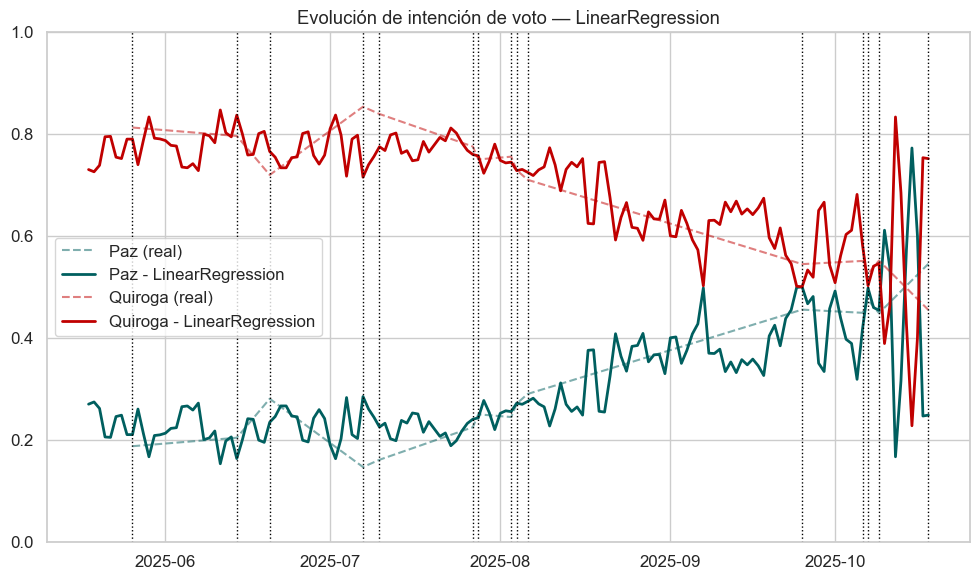

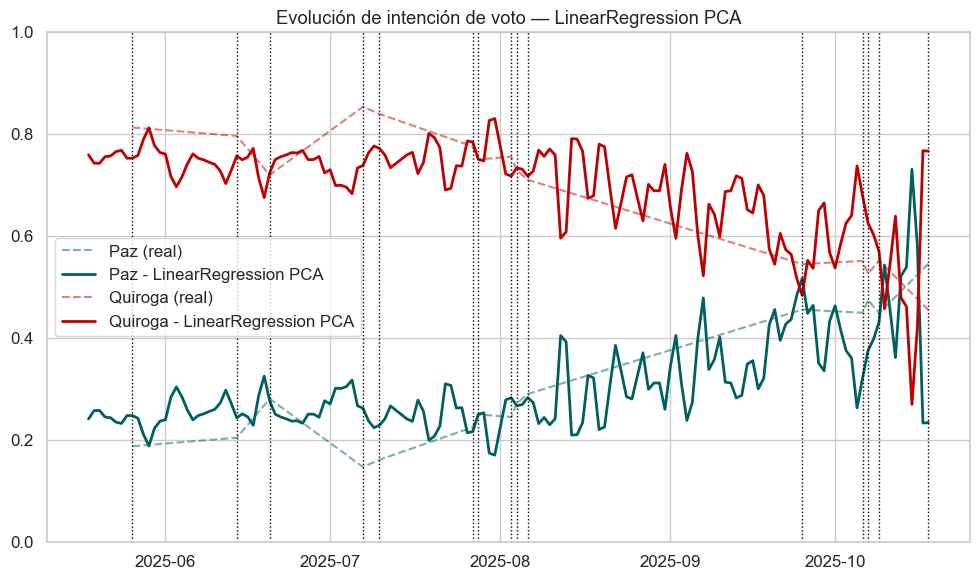

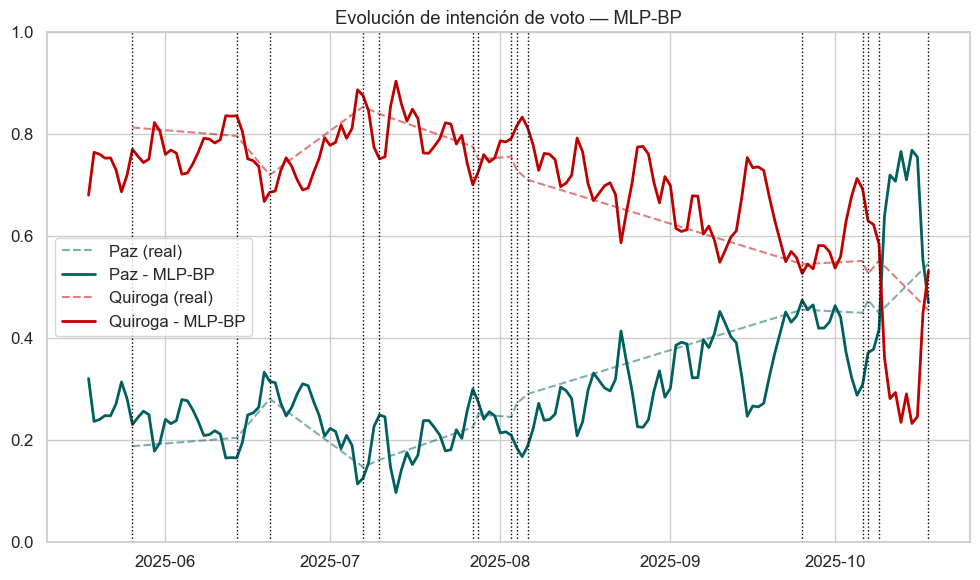

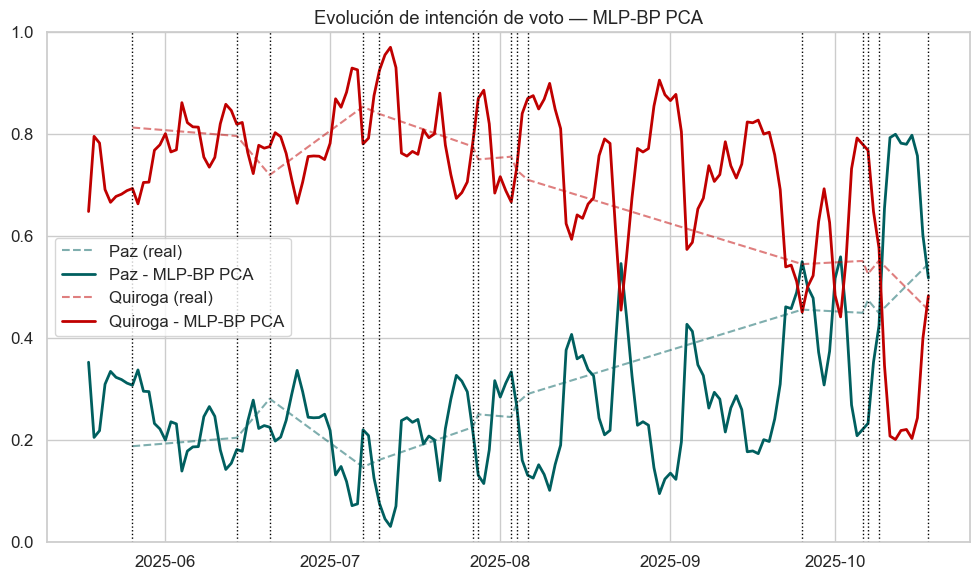

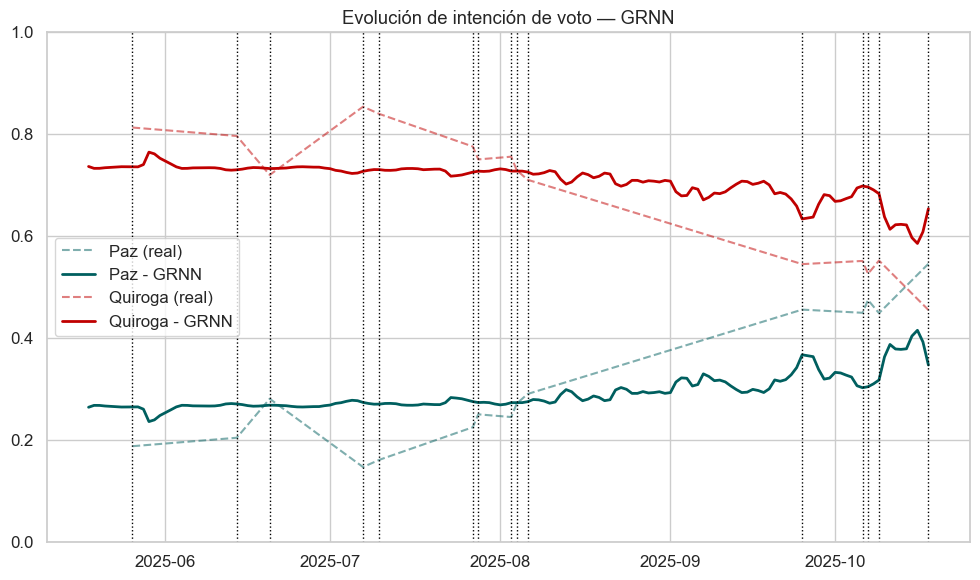

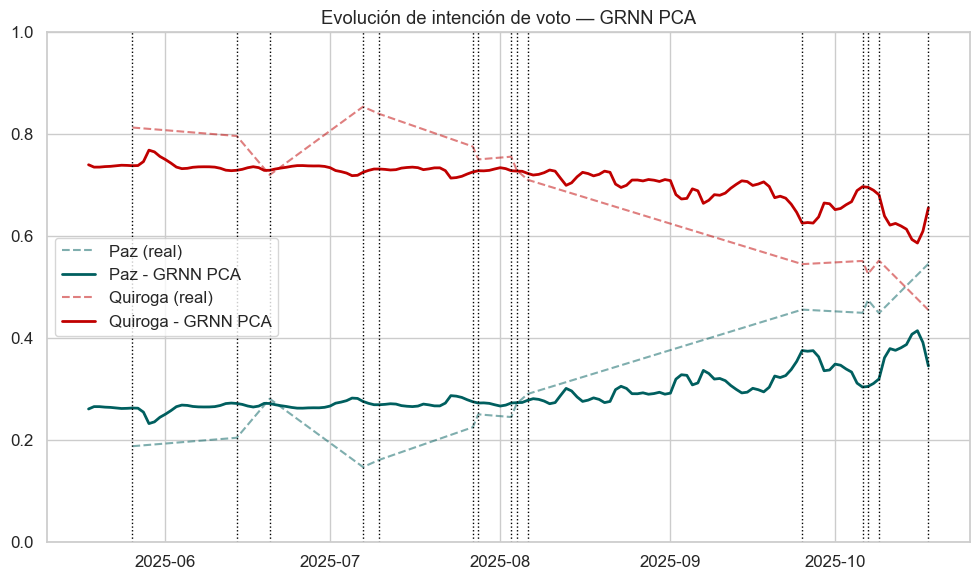

In [41]:
# ============================================
#  Gráficos comparativos (líneas continuas)
# ============================================
sns.set(style="whitegrid", font_scale=1.1)

for nombre_modelo in modelos.keys():
    plt.figure(figsize=(10,6))

    for cand in ['Paz', 'Quiroga']:
        sub = df[df['account'].str.lower()==cand.lower()].sort_values('date')
        ckey = cand.lower()

        # Intención real (discontinua)
        plt.plot(sub['date'], sub['IntencionVotoReal'],
                 '--', color=colors[ckey], alpha=0.5, label=f'{cand} (real)')

        # Predicción (continua)
        plt.plot(sub['date'], sub[nombre_modelo.replace(" ","_")],
                 '-', color=colors[ckey], linewidth=2,
                 label=f'{cand} - {nombre_modelo}')

    for vline in list(polls['fecha']) + [election_date]:
        plt.axvline(vline, color='black', linestyle=':', linewidth=1)

    plt.title(f"Evolución de intención de voto — {nombre_modelo}")
    plt.ylim(0,1)
    plt.legend()
    plt.tight_layout()
    plt.show()


# **Optimización de parámetros**

In [42]:
# ==========================================================
# 1️⃣ GRNN con parámetros ajustables
# ==========================================================
def grnn_predict_param(X_train, y_train, X_test, sigma, k=1.0):
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32).view(-1)
    Xte = torch.tensor(X_test, dtype=torch.float32)
    sigma2 = float(sigma)**2
    preds = []
    with torch.no_grad():
        for x in Xte:
            d2 = torch.sum((Xtr - x)**2, dim=1)
            w  = torch.exp(-d2 / (2 * sigma2))
            sw = torch.sum(w)
            yhat = (torch.sum(w * ytr) / (sw + 1e-12)).item()
            preds.append(np.clip(yhat, 0, 1))
    return np.array(preds)

# ==========================================================
# 2️⃣ Validación temporal con expansión (sin fuga)
# ==========================================================
def temporal_cv_score(modelo, X, y, splits=3, **params):
    tscv = TimeSeriesSplit(n_splits=splits)
    maes = []
    for train_idx, test_idx in tscv.split(X):
        Xtr, Xv = X[train_idx], X[test_idx]
        ytr, yv = y[train_idx], y[test_idx]

        if modelo == "MLP":
            from sklearn.neural_network import MLPRegressor
            m = MLPRegressor(**params, max_iter=4000, random_state=42)
            m.fit(Xtr, ytr)
            ypred = np.clip(m.predict(Xv), 0, 1)

        elif modelo == "GRNN":
            sigma = params.get('sigma', 0.3)
            k = params.get('k', 0.8)
            ypred = grnn_predict_param(Xtr, ytr, Xv, sigma, k)

        elif modelo == "LR":
            from sklearn.linear_model import LinearRegression
            m = LinearRegression()
            m.fit(Xtr, ytr)
            ypred = np.clip(m.predict(Xv), 0, 1)

        maes.append(mean_absolute_error(yv, ypred))
    return np.mean(maes)

# ==========================================================
# 3️⃣ Espacios de búsqueda
# ==========================================================
grid_mlp = {
    'hidden_layer_sizes': [(16,8), (32,16), (48,24)],
    'learning_rate_init': [1e-3, 5e-4, 3e-4],
    'alpha': [0.01, 0.02, 0.05]
}

grid_grnn = {
    'sigma': [0.2, 0.4, 0.6, 0.8],
    'k': [0.5, 0.7, 1.0]
}

# ==========================================================
# 4️⃣ Búsqueda manual optimizada (Paz)
# ==========================================================
Xtrain, ytrain = Xs_tr_paz, y_train_paz

best = {}

# --- MLP ---
best['MLP'] = {'mae': 999}
for combo in product(*grid_mlp.values()):
    params = dict(zip(grid_mlp.keys(), combo))
    score = temporal_cv_score("MLP", Xtrain, ytrain, splits=3, **params)
    if score < best['MLP']['mae']:
        best['MLP'] = {'params': params, 'mae': score}

# --- GRNN ---
best['GRNN'] = {'mae': 999}
for combo in product(*grid_grnn.values()):
    params = dict(zip(grid_grnn.keys(), combo))
    score = temporal_cv_score("GRNN", Xtrain, ytrain, splits=3, **params)
    if score < best['GRNN']['mae']:
        best['GRNN'] = {'params': params, 'mae': score}

print("\n=== Mejores hiperparámetros encontrados ===")
for m, res in best.items():
    print(f"{m}: {res['params']} | MAE={res['mae']:.4f}")



=== Mejores hiperparámetros encontrados ===
MLP: {'hidden_layer_sizes': (48, 24), 'learning_rate_init': 0.001, 'alpha': 0.01} | MAE=0.1818
GRNN: {'sigma': 0.8, 'k': 0.5} | MAE=0.1285


# **Uso de Lags y ponderación**

Buscamos que pueda aprender cuando un candidato deja de ser el favorito

c:\Users\juansoag\AppData\Local\miniconda3\envs\pitchlab\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


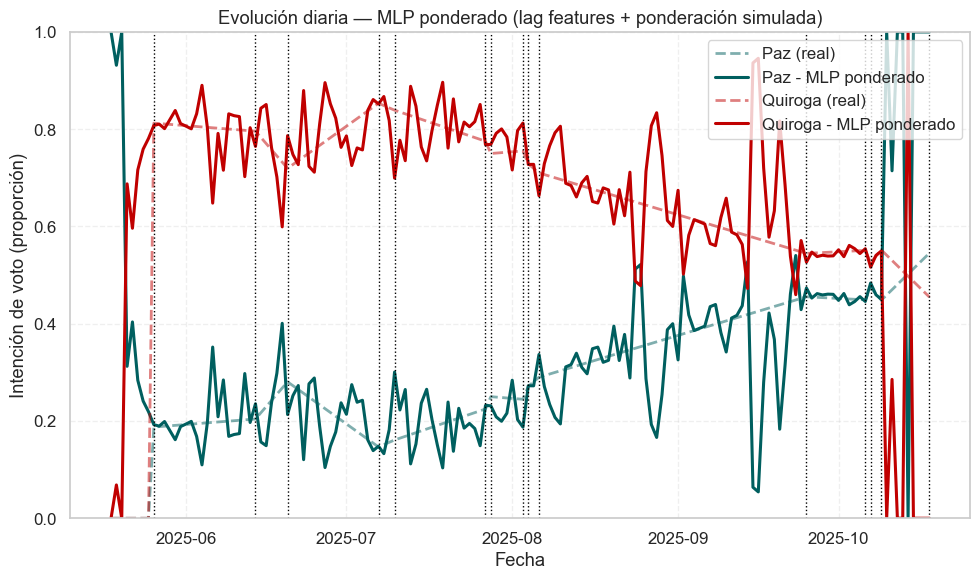

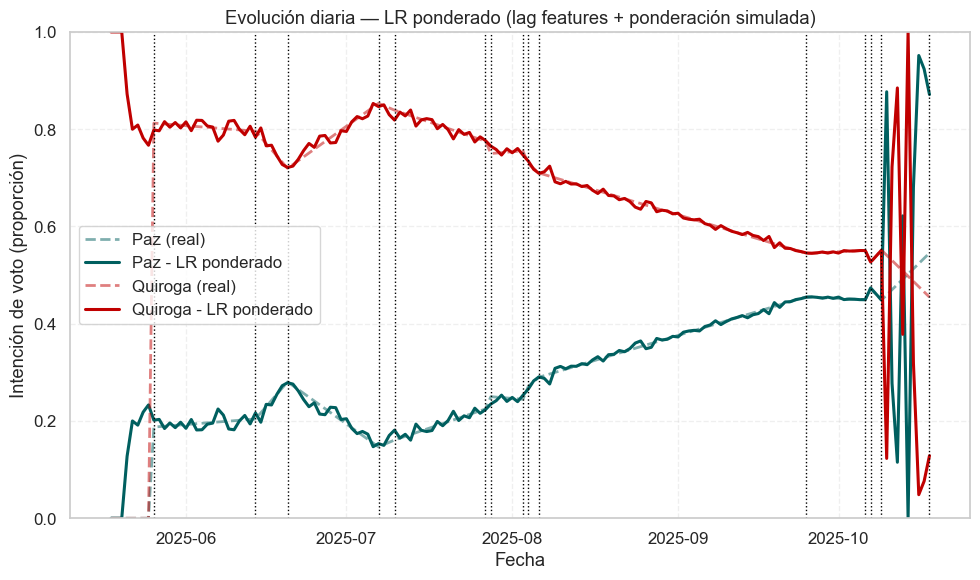

In [43]:
# ==========================================================
# 1️⃣ Generar LAG FEATURES (memoria de n días)
# ==========================================================
lags = [1, 2, 3]
df_lag = df.copy().sort_values(['account', 'date'])
cols_features = df.select_dtypes(include=[np.number]).columns.drop('IntencionVotoReal', errors='ignore')

for lag in lags:
    for col in cols_features:
        df_lag[f"{col}_lag{lag}"] = df_lag.groupby('account')[col].shift(lag)

df_lag = df_lag.fillna(0)

# ==========================================================
# 2️⃣ Separar entrenamiento y predicción
# ==========================================================
mask_paz = df_lag['account'].str.lower() == 'paz'
mask_q   = df_lag['account'].str.lower() == 'quiroga'
mask_train = (df_lag['date'] >= first_poll) & (df_lag['date'] <= last_poll)
mask_pred  = (df_lag['date'] <= election_date)

X_all = df_lag.select_dtypes(include=[np.number]).drop(columns=['IntencionVotoReal'], errors='ignore')
y_all = df_lag['IntencionVotoReal']

X_train_paz = X_all[mask_paz & mask_train]
y_train_paz = y_all[mask_paz & mask_train].values
X_pred_paz  = X_all[mask_paz & mask_pred]
dates_paz   = df_lag.loc[mask_paz & mask_pred, 'date'].values

idx_q_by_date = df_lag.loc[mask_q & mask_pred, ['date']].reset_index().set_index('date')['index']

# ==========================================================
# 3️⃣ Ponderación temporal (más peso a días recientes)
# ==========================================================
dias_a_eleccion = (election_date - df_lag.loc[mask_paz & mask_train, 'date']).dt.days.values
pesos_temporales = np.exp(-dias_a_eleccion / 10)
pesos_temporales = pesos_temporales / pesos_temporales.max()

# Replicar filas según peso (discretizado)
rep_factors = np.clip((pesos_temporales * 10).astype(int) + 1, 1, 10)

X_train_weighted = np.repeat(X_train_paz.values, rep_factors, axis=0)
y_train_weighted = np.repeat(y_train_paz, rep_factors, axis=0)

# ==========================================================
# 4️⃣ Escalar sin fuga
# ==========================================================
scaler = StandardScaler().fit(X_train_weighted)
Xs_tr_paz = scaler.transform(X_train_weighted)
Xs_pp_paz = scaler.transform(X_pred_paz)

# ==========================================================
# 5️⃣ Entrenamiento (MLP y LR)
# ==========================================================
mlp_w = MLPRegressor(hidden_layer_sizes=(32,16),
                     learning_rate_init=0.001,
                     alpha=0.03,
                     activation='relu',
                     solver='adam',
                     max_iter=4000,
                     random_state=42)

mlp_w.fit(Xs_tr_paz, y_train_weighted)
paz_mlp_w = np.clip(mlp_w.predict(Xs_pp_paz), 0, 1)

# Línea base: Regresión Lineal
lr = LinearRegression().fit(Xs_tr_paz, y_train_weighted)
paz_lr_w = np.clip(lr.predict(Xs_pp_paz), 0, 1)

# ==========================================================
# 6️⃣ Volcar resultados al DataFrame
# ==========================================================
df_lag['Pred_MLP_weighted'] = np.nan
df_lag['Pred_LR_weighted']  = np.nan
df_lag.loc[X_pred_paz.index, 'Pred_MLP_weighted'] = paz_mlp_w
df_lag.loc[X_pred_paz.index, 'Pred_LR_weighted']  = paz_lr_w

# Complementar para Quiroga = 1 - Paz
for fecha, p in zip(dates_paz, paz_mlp_w):
    if fecha in idx_q_by_date:
        df_lag.at[idx_q_by_date.loc[fecha], 'Pred_MLP_weighted'] = 1 - p
for fecha, p in zip(dates_paz, paz_lr_w):
    if fecha in idx_q_by_date:
        df_lag.at[idx_q_by_date.loc[fecha], 'Pred_LR_weighted'] = 1 - p

# ==========================================================
# 7️⃣ Gráfico comparativo
# ==========================================================
sns.set(style="whitegrid", font_scale=1.1)
cand_colors = {'paz': '#005F5F', 'quiroga': '#C00000'}

for modelo, col in [('MLP ponderado', 'Pred_MLP_weighted'), ('LR ponderado', 'Pred_LR_weighted')]:
    plt.figure(figsize=(10,6))
    for cand in ['Paz','Quiroga']:
        sub = df_lag[df_lag['account'].str.lower()==cand.lower()].sort_values('date')
        ckey = cand.lower()
        plt.plot(sub['date'], sub['IntencionVotoReal'], '--',
                 color=cand_colors[ckey], alpha=0.5, linewidth=2, label=f'{cand} (real)')
        plt.plot(sub['date'], sub[col], '-',
                 color=cand_colors[ckey], linewidth=2.2, label=f'{cand} - {modelo}')
    for vline in list(polls['fecha']) + [election_date]:
        plt.axvline(vline, color='black', linestyle=':', linewidth=1)
    plt.title(f"Evolución diaria — {modelo} (lag features + ponderación simulada)")
    plt.xlabel("Fecha"); plt.ylabel("Intención de voto (proporción)")
    plt.ylim(0,1); plt.grid(alpha=0.3, linestyle='--')
    plt.legend(loc='best'); plt.tight_layout(); plt.show()

